In [1]:
import torch , math
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from models.selfattn import AttentionWrapper
from models.unet import get_time_embedding
from models.scheduler import nosieADD , step
import matplotlib.pyplot as plt

device = 'cuda'

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

traindata = datasets.CIFAR10(download = True , root = './data' , train = True , transform = transform)
trainloader = DataLoader(traindata , shuffle = True , batch_size = 16)

Files already downloaded and verified


In [3]:
class UNET(nn.Module):
    def __init__(self, in_channels , timedim):
        super().__init__()
        self.timedim = timedim

        self.label_emb = nn.Embedding(11 , embedding_dim = timedim)

        self.enc1_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.SiLU()
        )
        self.timeMLP1 = nn.Sequential(
            nn.Linear(timedim , 64),
            nn.SiLU() ,
            nn.Linear(64 , 64)
        )

        self.pool1 = nn.Conv2d(64, 64, kernel_size=2, stride=2) # 28 -> 14


        self.enc2_conv = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.SiLU()
        )
        self.timeMLP2 = nn.Sequential(
            nn.Linear(timedim , 128),
            nn.SiLU() ,
            nn.Linear(128 , 128)
        )

        self.pool2 = nn.Conv2d(128, 128, kernel_size=2, stride=2) # 14 -> 7


        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.SiLU(),
            AttentionWrapper(256 , 8),
        )

        self.timeMLP3 = nn.Sequential(
            nn.Linear(timedim , 256),
            nn.SiLU() ,
            nn.Linear(256 , 256)
        )

        self.up1 = nn.ConvTranspose2d(256 , 128 , kernel_size = 2 , stride = 2)

        self.up1_conv = nn.Sequential(
            nn.Conv2d(256 , 128 , kernel_size = 3 , padding = 1),
            nn.SiLU(),
            nn.Conv2d(128 , 128 , kernel_size = 3 , padding = 1),
            nn.SiLU()
        )
        self.timeMLP4 = nn.Sequential(
            nn.Linear(timedim , 128),
            nn.SiLU() ,
            nn.Linear(128 , 128)
        )


        self.up2 = nn.ConvTranspose2d(128 , 64 , kernel_size = 2 , stride = 2)

        self.up2_conv = nn.Sequential(
            nn.Conv2d(128 , 64 , kernel_size = 3 , padding = 1),
            nn.SiLU() ,
            nn.Conv2d(64 ,  64 , kernel_size = 3 , padding = 1),
            nn.SiLU()
        )
        self.timeMLP5 = nn.Sequential(
            nn.Linear(timedim , 64),
            nn.SiLU() ,
            nn.Linear(64 , 64)
        )


        self.final = nn.Conv2d(64 , in_channels , kernel_size = 1 , padding = 0)

    def forward(self , x , t , y):
        t_emb = get_time_embedding(t, self.timedim, device=t.device)
        label_emb = self.label_emb(y)
        time_embed = t_emb + label_emb
        
        time1_4d = self.timeMLP1(time_embed)[:, :, None, None]
        time2_4d = self.timeMLP2(time_embed)[:, :, None, None]
        time3_4d = self.timeMLP3(time_embed)[:, :, None, None]
        time4_4d = self.timeMLP4(time_embed)[:, :, None, None]
        time5_4d = self.timeMLP5(time_embed)[:, :, None, None]



        enc1 = self.enc1_conv(x) + time1_4d
        
        #pool1 = self.pool1(enc1)

        enc2 = self.enc2_conv(enc1) + time2_4d
        #pool2 = self.pool2(enc2)

        bottleneck = self.bottleneck(enc2) + time3_4d

        dec1 = self.up1(bottleneck) + time4_4d
        dec1 = F.interpolate(dec1, size=enc2.shape[2:], mode='nearest')
        dec1 = torch.cat([dec1, enc2], dim=1)
        dec1 = self.up1_conv(dec1)

        dec2 = self.up2(dec1) + time5_4d
        dec2 = F.interpolate(dec2, size=enc1.shape[2:], mode='nearest')
        dec2 = torch.cat([dec2, enc1], dim=1)
        dec2 = self.up2_conv(dec2)

        final = self.final(dec2) 

        return final
    

In [4]:
class RESIDUAL(nn.Module):
    def __init__(self , inchannel , outchannel):
        super().__init__()

        self.inchannel = inchannel
        self.outchannel = outchannel

        # block 1
        self.grp1 = nn.GroupNorm(num_groups = 8 , num_channels = inchannel)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(inchannel , outchannel , kernel_size = 3 , padding = 1) # batch , channel , in , out

        # block 2
        self.grp2 = nn.GroupNorm(num_groups = 8 , num_channels = outchannel)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(outchannel , outchannel , kernel_size = 3 , padding = 1) # batch , channel , in , out

        # shortcut connection for fallback

        if inchannel != outchannel:
            self.shortcut = nn.Conv2d(inchannel , outchannel , kernel_size = 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self , x):
        h = self.conv1(self.act1(self.grp1(x))) # batch , channel , in , out

        h = self.conv2(self.act2(self.grp2(h))) # batch , channel , in , out

        return h + self.shortcut(x)

In [ ]:
class LatentVAE(nn.Module):
    def __init__(self, latentdim, inchannel):
        super().__init__()
        
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.GroupNorm(8, cout),
                nn.SiLU(),
                nn.Conv2d(cout, cout, 3, padding=1),
                nn.GroupNorm(8, cout),
                nn.SiLU()
            )
        
        # ── Encoder ──────────────────────────────────────────
        self.enc1 = block(inchannel, 128)
        self.res1 = nn.Sequential(RESIDUAL(128, 128), RESIDUAL(128, 128))

        self.pool1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            RESIDUAL(128, 128),
            nn.SiLU()
        )

        self.enc2 = block(128, 256)
        self.res2 = nn.Sequential(RESIDUAL(256, 256), RESIDUAL(256, 256))

        self.pool2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            RESIDUAL(256, 256),
            nn.SiLU()
        )

        self.enc3 = block(256, 512)
        self.res3 = nn.Sequential(
            RESIDUAL(512, 512),
            RESIDUAL(512, 512),
            RESIDUAL(512, 512)   # extra depth at bottleneck
        )

        self.mu     = nn.Conv2d(512, latentdim, 1)
        self.logvar = nn.Conv2d(512, latentdim, 1)

        # ── Decoder ──────────────────────────────────────────
        self.res_latent = nn.Sequential(
            RESIDUAL(latentdim, latentdim),
            RESIDUAL(latentdim, latentdim)  # refine latent before decoding
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(latentdim, 512, 2, stride=2),
            RESIDUAL(512, 512),
            nn.SiLU()
        )
        self.dec1 = block(512, 256)
        self.res4 = nn.Sequential(RESIDUAL(256, 256), RESIDUAL(256, 256))

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            RESIDUAL(128, 128),
            nn.SiLU()
        )
        self.dec2 = block(128, 128)
        self.res5 = nn.Sequential(RESIDUAL(128, 128), RESIDUAL(128, 128))

        self.final = nn.Sequential(
            nn.Conv2d(128, inchannel, 1),
            nn.Tanh() 
        )

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        x = self.res1(self.enc1(x))          # [B, 128, 32, 32]
        x = self.res2(self.enc2(self.pool1(x)))  # [B, 256, 16, 16]
        x = self.res3(self.enc3(self.pool2(x)))  # [B, 512,  8,  8]
        return x

    def decode(self, z):
        z = self.res_latent(z)               # [B, latentdim, 8, 8]
        z = self.res4(self.dec1(self.up1(z)))    # [B, 256, 16, 16]
        z = self.res5(self.dec2(self.up2(z)))    # [B, 128, 32, 32]
        return self.final(z)                

    def forward(self, x):
        b      = self.encode(x)
        mu     = self.mu(b)
        logvar = torch.clamp(self.logvar(b), -10, 10)
        z      = self.reparametrize(mu, logvar)
        recon  = self.decode(z)
        return recon, mu, logvar

In [8]:
unet , vae = UNET(16, 256) , LatentVAE(latentdim = 16 , inchannel = 3)
unet , vae = unet.to(device) , vae.to(device)

kl_aneal = 28000
global_step = 0
beta_final = 0.00001

In [7]:
vae.load_state_dict(torch.load('vae_final1.pth'))

/tmp/ipykernel_4627/607490508.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load('vae_final1.pth'))


<All keys matched successfully>

In [ ]:
optimizer1 = torch.optim.Adam(unet.parameters() , lr = 1e-4)
optimizer2 = torch.optim.Adam(vae.parameters() , lr = 1e-4)  

from pytorch_msssim import ssim

def vae_loss(recon, x, mu, logvar, epoch):
    mse  = F.mse_loss(recon, x)
    ssim_loss = 1 - ssim(recon, x, data_range=1.0, size_average=True)
    recon_loss = mse + 0.5 * ssim_loss
    
    kl_weight = min(epoch / 50, 1.0) * 0.00001
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_weight * kl, recon_loss, kl
# Add EMA wrapper
from copy import deepcopy

class EMA:
    def __init__(self, model, decay=0.9999):
        self.model = model
        self.shadow = deepcopy(model)
        self.decay = decay
        
    def update(self):
        for param, shadow_param in zip(self.model.parameters(), self.shadow.parameters()):
            shadow_param.data = self.decay * shadow_param.data + (1 - self.decay) * param.data

ema = EMA(vae, decay=0.9999)


In [10]:
for i in range(120):
    vae.train()

    total = {
        'total': 0.0,
        'recon': 0.0,
        'kl': 0.0,
        'mu_mean': 0.0,
        'mu_var': 0.0,
        'latent_var': 0.0
    }

    steps = 0

    for img, label in trainloader:
        img, label = img.to(device), label.to(device)

        if i > 18:
            kl_weight = min(beta_final, (global_step / kl_aneal) * beta_final)
            global_step += 1
        else:
            kl_weight = 0
            global_step += 1

        recon, mu, logvar = vae(img)

        loss, recon_loss, kl = vae_loss(recon, img, mu, logvar, kl_weight)

        if torch.isnan(loss):
            optimizer2.zero_grad()
            continue

        optimizer2.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        optimizer2.step()

        total['kl'] += kl.item()
        total['recon'] += recon_loss.item()
        total['total'] += loss.item()

        total['mu_mean'] += mu.mean().item()
        total['mu_var'] += mu.var().item()
        total['latent_var'] += torch.exp(logvar).mean().item()

        steps += 1
        ema.update()

    for k in total:
        total[k] /= steps

    print(
        f"Epoch {i+1} | "
        f"Loss {total['total']:.4f} | "
        f"Recon {total['recon']:.4f} | "
        f"KL {total['kl']:.4f} | "
        f"mu_mean {total['mu_mean']:.4f} | "
        f"mu_var {total['mu_var']:.4f} | "
        f"latent_var {total['latent_var']:.4f}"
    )

Epoch 1 | Loss 0.2074 | Recon 0.2074 | KL 125.1216 | mu_mean 1.1466 | mu_var 32.1752 | latent_var 212.4293
Epoch 2 | Loss 0.0982 | Recon 0.0982 | KL 13.7972 | mu_mean 0.6146 | mu_var 20.4108 | latent_var 0.0044
Epoch 3 | Loss 0.0602 | Recon 0.0602 | KL 10.4166 | mu_mean 0.4641 | mu_var 12.5540 | latent_var 0.0005
Epoch 4 | Loss 0.0419 | Recon 0.0419 | KL 9.4004 | mu_mean 0.3823 | mu_var 9.8784 | latent_var 0.0001
Epoch 5 | Loss 0.0341 | Recon 0.0341 | KL 8.8735 | mu_mean 0.3640 | mu_var 8.6715 | latent_var 0.0001
Epoch 6 | Loss 0.0285 | Recon 0.0285 | KL 8.5612 | mu_mean 0.3270 | mu_var 8.0243 | latent_var 0.0000
Epoch 7 | Loss 0.0249 | Recon 0.0249 | KL 8.4026 | mu_mean 0.3152 | mu_var 7.7015 | latent_var 0.0000
Epoch 8 | Loss 0.0214 | Recon 0.0214 | KL 8.2436 | mu_mean 0.3085 | mu_var 7.3808 | latent_var 0.0000
Epoch 9 | Loss 0.0185 | Recon 0.0185 | KL 8.1004 | mu_mean 0.3014 | mu_var 7.0963 | latent_var 0.0000
Epoch 10 | Loss 0.0162 | Recon 0.0162 | KL 8.0614 | mu_mean 0.2957 | mu_v

KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271061..0.95601565].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.9764706].


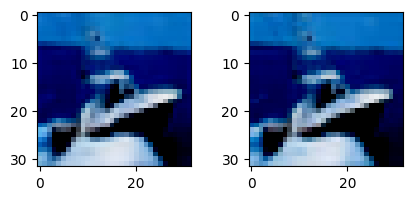

In [11]:
img , _ = traindata[8]
img = img.to(device).unsqueeze(0)

y , _ , _ = vae(img)

y = y.squeeze(0)
img = img.squeeze(0)

fig , axis = plt.subplots(1 , 2 , figsize=(5,2))
axis[0].imshow(y.detach().cpu().permute(1,2,0))
axis[1].imshow(img.cpu().permute(1,2,0))
plt.show()

In [12]:
torch.save(vae.state_dict() , "vae_final2.pth")

In [41]:
vae.load_state_dict(torch.load('vae_final2.pth'))

/tmp/ipykernel_4627/3023014826.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load('vae_final2.pth'))


<All keys matched successfully>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.8117647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8117647..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..0.75686276].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70980394..0.92941177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7254902..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.827451].


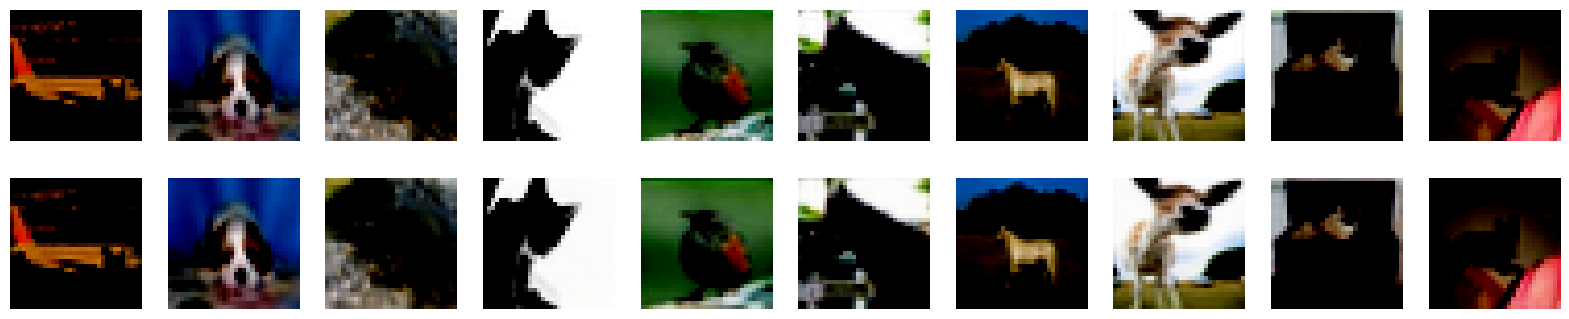

In [13]:
import torch
import matplotlib.pyplot as plt

vae.eval()

with torch.no_grad():
    x, _ = next(iter(trainloader))
    x = x.to(device)

    recon, _, _ = vae(x)

    x = x.cpu()
    recon = recon.cpu()

    recon = torch.clamp(recon, 0, 1)

    n = 10
    plt.figure(figsize=(20,4))

    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x[i].permute(1,2,0).numpy())
        ax.axis('off')

        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(recon[i].permute(1,2,0).numpy())
        ax.axis('off')

    plt.show()

In [14]:

latent_list = []
label_list = []

vae.eval()
with torch.no_grad():
    for img, label in trainloader:
        img = img.to(device)
        _ , mu, logvar = vae(img)
        z = vae.reparametrize(mu, logvar)
        latent_list.append(z.cpu())
        label_list.append(label)

all_latents = torch.cat(latent_list, dim=0)
all_labels = torch.cat(label_list, dim=0)
torch.save({'latents': all_latents, 'labels': all_labels}, 'cifar_laten.pth')


In [15]:
data = torch.load("cifar_laten.pth")

latents = data["latents"]
labels = data["labels"]
from torch.utils.data import TensorDataset, DataLoader

latent_dataset = TensorDataset(latents, labels)

latent_loader = DataLoader(
    latent_dataset,
    batch_size=64,
    shuffle=True
)


/tmp/ipykernel_35095/1578908077.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("cifar_laten.pth")


In [16]:
latents[1].shape

torch.Size([16, 8, 8])

In [17]:
loss_running = 0.0
# unet training 
for i in range(100):
    unet.train()
    for img , label in latent_loader:
        img , label = img.to(device) , label.to(device)

        t = torch.randint(0, 1000, (img.shape[0],), device=device).long()
        noise = torch.randn_like(img)
        
        noise_latents , _ = nosieADD(img , noise , t)
        null_label = torch.full_like(label, 10)
        mask = torch.bernoulli(torch.full(label.shape, 0.1, device=device)).bool()
        training_label = torch.where(mask, null_label, label)

        pred = unet(noise_latents , t , training_label)
        loss = F.mse_loss(pred , noise)

        
        if torch.isnan(loss):
            optimizer1.zero_grad() ; continue

        optimizer1.zero_grad()

        loss.backward()
        nn.utils.clip_grad_norm_(unet.parameters() , max_norm = 1.0)
        optimizer1.step()

        loss_running += loss.item() / img.shape[0]
    print(f" loss for eporch {i} : {loss.item()}")
    torch.save(unet.state_dict() , 'unetbig.pth')

 loss for eporch 0 : 0.5226855874061584
 loss for eporch 1 : 0.46061524748802185
 loss for eporch 2 : 0.4737227261066437
 loss for eporch 3 : 0.2320120483636856
 loss for eporch 4 : 0.23943276703357697
 loss for eporch 5 : 0.3706083595752716
 loss for eporch 6 : 0.3957086503505707
 loss for eporch 7 : 0.29867666959762573
 loss for eporch 8 : 0.3690858483314514
 loss for eporch 9 : 0.2886563837528229
 loss for eporch 10 : 0.14954712986946106
 loss for eporch 11 : 0.3045194447040558
 loss for eporch 12 : 0.2634151577949524
 loss for eporch 13 : 0.13662636280059814
 loss for eporch 14 : 0.2943747043609619
 loss for eporch 15 : 0.28655290603637695
 loss for eporch 16 : 0.23463621735572815
 loss for eporch 17 : 0.31848159432411194
 loss for eporch 18 : 0.1323188990354538
 loss for eporch 19 : 0.42229729890823364
 loss for eporch 20 : 0.19704531133174896
 loss for eporch 21 : 0.18814799189567566
 loss for eporch 22 : 0.23555226624011993
 loss for eporch 23 : 0.3796701431274414
 loss for epor

In [69]:
unet.load_state_dict(torch.load('unetbigno.pth'))
vae.load_state_dict(torch.load('vae_final2.pth'))


/tmp/ipykernel_4627/1046045878.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet.load_state_dict(torch.load('unetbigno.pth'))
/tmp/ipykernel_4627/1046045878.py:2: Fut

<All keys matched successfully>

In [18]:
img, label = next(iter(trainloader))
img = img.to(device)

with torch.no_grad():
    z , _ , _ = vae(img)

print("image shape:", img.shape)
print("latent shape:", z.shape)

image shape: torch.Size([16, 3, 32, 32])
latent shape: torch.Size([16, 3, 32, 32])


In [22]:
from tqdm import tqdm
def sample_digit(unet , vae , noiser , n = 10 , device = device , cfg_scale = 7.0 , label = None):
    unet.eval()
    vae.eval()
    n = int(n)

    x = torch.randn((n , 16 , 4 , 4 ), device = device)
    label = label if label is not None else torch.arange(n, device=device) 
    with torch.no_grad(): 
        for i in tqdm(reversed(range(0 , 1000))):
            t = torch.full((n,) , i , device = device , dtype = torch.long)

            pred_noise = unet(x , t , label)
            null_label = torch.full_like(label, 10)
            eps_uncond = unet(x, t, null_label)

            eps_final = eps_uncond + cfg_scale * (pred_noise - eps_uncond)

            x = noiser(x , eps_final , t)
        
        out = vae.decode(x)

    return out


In [23]:
import torch , math
import torch.nn as nn

device = 'cuda'

def scheduler(timesteps = 1000):
    beta = torch.linspace(1e-4 , 0.02 , timesteps , device = device)

    alpha = 1.0 - beta
    alpha_hat = torch.cumprod(alpha , dim = 0)

    alpha_hat_sqrt = torch.sqrt(alpha_hat)
    one_minus_hat_sqrt = torch.sqrt(1.0 - alpha_hat)

    return {
        'beta' : beta ,
        'alpha' : alpha ,
        'alpha_hat' : alpha_hat ,
        'alpha_hat_sqrt' : alpha_hat_sqrt ,
        'one_minus_hat_sqrt' : one_minus_hat_sqrt
    }


sched = scheduler()
one_minus_hat_sqrt = sched['one_minus_hat_sqrt']
alpha_hat_sqrt = sched['alpha_hat_sqrt']
alpha = sched['alpha']
alpha_hat = sched['alpha_hat']


def ddim_step(x_t, pred_noise, t, eta=0.0):
    # Handle batched timesteps
    t_prev = torch.clamp(t - 1, min=0)

    # Reshape for broadcasting
    alpha_t = alpha_hat_sqrt[t].view(-1, 1, 1, 1)
    alpha_prev = alpha_hat_sqrt[t_prev].view(-1, 1, 1, 1)
    one_minus_sqrt_t = one_minus_hat_sqrt[t].view(-1, 1, 1, 1)

    # Predict x0
    x0_pred = (x_t - one_minus_sqrt_t * pred_noise) / alpha_t

    # Deterministic DDIM update (eta=0)
    x_prev = alpha_prev * x0_pred + torch.sqrt(1 - alpha_prev**2) * pred_noise

    return x_prev

1000it [00:01, 512.91it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9020953..0.9203985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92599654..0.6476845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8602634..0.56175506].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.57195055..0.37574092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9377186..0.54079735].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18758747..0.28598115].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] f

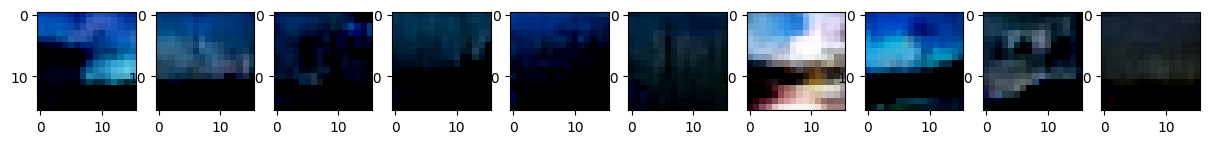

In [24]:
label = torch.full((n,), 8, device=device)
samples = sample_digit(unet, vae , ddim_step , label = label)
fig, axis = plt.subplots(1, 10, figsize=(15 , 2))
for i in range(10):
    axis[i].imshow(samples[i].cpu().permute(1, 2, 0))
plt.show()

In [25]:
def steep(x_t, predicted_noise, t):
    device = x_t.device
    batch_size = x_t.shape[0]

    if isinstance(t, int):
        t = torch.full((batch_size,), t, device=device, dtype=torch.long)
    elif torch.is_tensor(t) and t.dim() == 0:
        t = t.expand(batch_size)

    beta_t = sched['beta'][t].to(device).view(batch_size,1,1,1)
    alpha_t = sched['alpha'][t].to(device).view(batch_size,1,1,1)
    alpha_bar_t = sched['alpha_hat'][t].to(device).view(batch_size,1,1,1)

    coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
    mean = (1 / torch.sqrt(alpha_t)) * (x_t - coeff * predicted_noise)

    t_prev = torch.clamp(t - 1, min=0)
    alpha_bar_prev = sched['alpha_hat'][t_prev].to(device)
    alpha_bar_prev[t==0] = 1.0
    alpha_bar_prev = alpha_bar_prev.view(batch_size,1,1,1)

    sigma_t = torch.sqrt(beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t))

    noise_mask = (t > 0).float().view(batch_size,1,1,1)
    noise = torch.randn_like(x_t) * noise_mask

    return mean + sigma_t * noise

1000it [00:02, 482.07it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76114297..0.154144].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.58913565..0.463341].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29442194..0.13540111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2681671..0.39481422].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5775639..0.23988932].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39225787..0.3083961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for

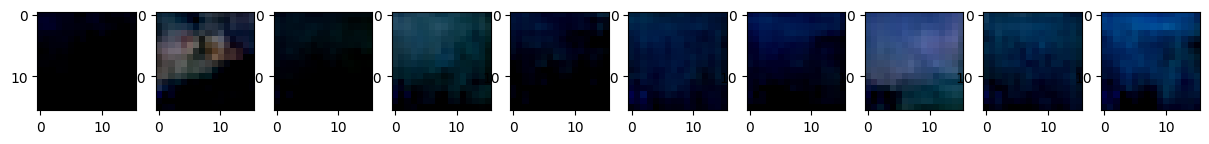

In [26]:
samples = sample_digit(unet, vae , steep , label = label)
fig, axis = plt.subplots(1, 10, figsize=(15 , 2))
for i in range(10):
    axis[i].imshow(samples[i].cpu().permute(1, 2, 0))
plt.show()

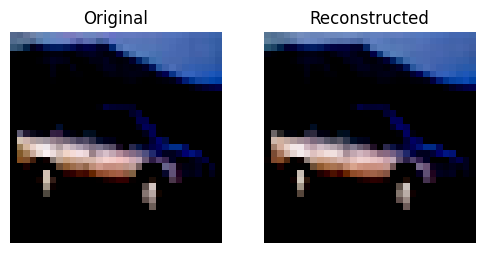

In [27]:
import torch
import matplotlib.pyplot as plt

# Function to show images side by side
def show_images(images, titles=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for i, img in enumerate(images):
        img = img.detach().cpu()
        if img.shape[0] == 3:  # (C, H, W) -> (H, W, C)
            img = img.permute(1, 2, 0)
        axes[i].imshow(img.clip(0, 1))
        axes[i].axis('off')
        if titles:
            axes[i].set_title(titles[i])
    plt.show()

# Pick a CIFAR image
# Pick a CIFAR image
original, _ = traindata[4]  # unpack tuple: image, label
original = original.unsqueeze(0).to(device)  # Add batch dimension

# Pass through VAE
vae.eval()
with torch.no_grad():
    reconstructed, mu, logvar = vae(original)

# Remove batch dimension for visualization
original_img = original[0]
reconstructed_img = reconstructed[0]

# Show original vs reconstructed
show_images([original_img, reconstructed_img], titles=['Original', 'Reconstructed'])

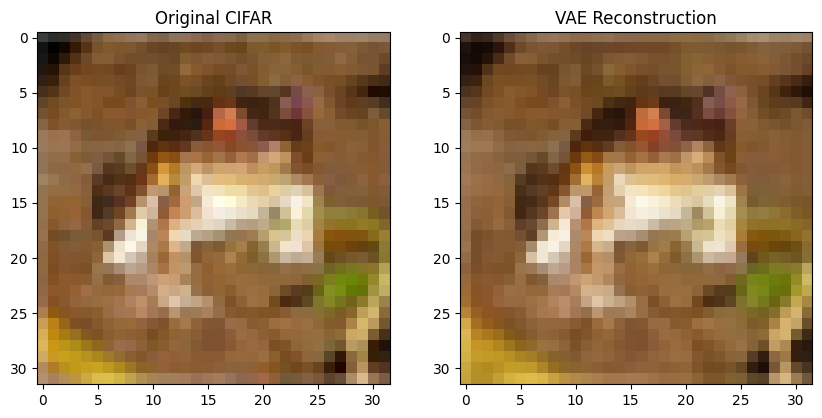

Class: frog


In [28]:
# Load a CIFAR image
img, label = traindata[0]
img = img.unsqueeze(0).to(device)  # Add batch dim

# VAE reconstruction
with torch.no_grad():
    recon, mu, logvar = vae(img)

# Show side by side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[0].cpu().permute(1,2,0) * 0.5 + 0.5)  # Denormalize
axes[0].set_title("Original CIFAR")
axes[1].imshow(recon[0].cpu().permute(1,2,0) * 0.5 + 0.5)
axes[1].set_title("VAE Reconstruction")
plt.show()

# Can you still tell what it is?
print(f"Class: {traindata.classes[label]}")

In [89]:
class aLatentVAE(nn.Module):
    def __init__(self, latentdim, inchannel):
        super().__init__()
        
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.GroupNorm(8, cout),
                nn.SiLU(),
                nn.Conv2d(cout, cout, 3, padding=1),
                nn.GroupNorm(8, cout),
                nn.SiLU()
            )
        
        # Encoder: [inchannel → 128 → 256 → 512]
        self.enc1 = block(inchannel, 128)
        self.pool1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            RESIDUAL(128, 128),
            nn.SiLU()
        )
        self.enc2 = block(128, 256)
        self.pool2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            RESIDUAL(256, 256),
            nn.SiLU()
        )
        self.enc3 = block(256, 512)
        self.pool3 = nn.Sequential(
            nn.Conv2d(512, 512, 3, stride=2, padding=1),
            RESIDUAL(512, 512),
            nn.SiLU()
        )
        
        self.mu     = nn.Conv2d(512, latentdim, 1)
        self.logvar = nn.Conv2d(512, latentdim, 1)
        
        # Decoder: [latentdim → 512 → 256 → 128 → inchannel]
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(latentdim, 512, 2, stride=2),
            RESIDUAL(512, 512),
            nn.SiLU()
        )
        self.dec1 = block(512, 512)
        
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2),
            RESIDUAL(256, 256),
            nn.SiLU()
        )
        self.dec2 = block(256, 256)
        
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            RESIDUAL(128, 128),
            nn.SiLU()
        )
        self.dec3 = block(128, 128)
        
        self.final = nn.Conv2d(128, inchannel, 1)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(self.pool1(x))
        x = self.enc3(self.pool2(x))
        x = self.pool3(x)
        return x

    def decode(self, z):
        z = self.dec1(self.up1(z))
        z = self.dec2(self.up2(z))
        z = self.dec3(self.up3(z))
        return self.final(z)

    def forward(self, x):
        b = self.encode(x)
        mu     = self.mu(b)
        logvar = torch.clamp(self.logvar(b), -10, 10)
        z      = self.reparametrize(mu, logvar)
        recon  = self.decode(z)
        return recon, mu, logvar

x = torch.randn(1 , 3 , 32 , 32 , device = 'cuda')
model = aLatentVAE(8 , 3)
model.to(device)

y, _ , _ = model(x)
y.shape

torch.Size([1, 3, 32, 32])